# Executive Hotel Booking EDA Report

This report analyzes hotel booking demand, revenue, cancellations, customer mix, and service quality. It follows an end-to-end workflow: data understanding, quality assessment, cleaning, exploratory analysis, business insights, and management recommendations.

**Scope:** Booking-level data from the supplied hotel booking dataset. Monetary fields are treated as revenue/price measures in the dataset's currency units. Correlation and descriptive comparisons indicate association, not causation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

DATA_PATH = Path('Day15_Executive_Hotel_Booking_EDA_Dataset.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')

raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
display(raw.head())
display(raw.dtypes.rename('dtype').to_frame())

Raw shape: 25,180 rows x 35 columns


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


,dtype
Booking_ID,str
Hotel_Type,str
Hotel_Location,str
Booking_Date,str
Arrival_Date,str
Lead_Time_Days,int64
Weekend_Nights,int64
Weekday_Nights,int64
Adults,int64
Children,float64


## 1. Data Quality Audit

The audit checks structure, missingness, duplicates, data types, inconsistent categorical values, invalid business values, and outliers. Missing agent/company identifiers are treated as structural missingness because direct bookings may not have an intermediary.

In [2]:
audit = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'missing_count': raw.isna().sum(),
    'missing_pct': (raw.isna().mean() * 100).round(2),
    'unique_values': raw.nunique(dropna=False)
}).sort_values('missing_count', ascending=False)
print(f'Duplicate rows: {raw.duplicated().sum():,}')
display(audit[audit['missing_count'] > 0])

categorical_columns = raw.select_dtypes(include='str').columns
inconsistent_values = {
    column: sorted(raw[column].dropna().astype(str).loc[lambda values: values != values.str.strip()]
                   .unique().tolist())
    for column in categorical_columns
}
inconsistent_values = {column: values for column, values in inconsistent_values.items() if values}
print('Whitespace inconsistencies:', inconsistent_values)

invalid_checks = pd.Series({
    'non_positive_total_nights': (raw['Total_Nights'] <= 0).sum(),
    'negative_adr': (raw['ADR'] < 0).sum(),
    'negative_revenue': (raw['Estimated_Revenue'] < 0).sum(),
    'satisfaction_outside_1_5': (~raw['Satisfaction_Score'].between(1, 5)).sum(),
    'canceled_flag_not_0_or_1': (~raw['Is_Canceled'].isin([0, 1])).sum()
})
display(invalid_checks.rename('records').to_frame())

Duplicate rows: 180


,dtype,missing_count,missing_pct,unique_values
Company_ID,float64,20729,82.32,120
Country,str,466,1.85,25
Agent_ID,float64,304,1.21,180
Meal_Type,str,245,0.97,10
Satisfaction_Score,float64,164,0.65,277
Children,float64,121,0.48,6
Hotel_Location,str,106,0.42,12
ADR,float64,82,0.33,13270


Whitespace inconsistencies: {'Market_Segment': ['Online TA '], 'Meal_Type': [' B&B ', 'BB ']}


,records
non_positive_total_nights,0
negative_adr,0
negative_revenue,0
satisfaction_outside_1_5,166
canceled_flag_not_0_or_1,0


## 2. Cleaning and Feature Engineering

Duplicate records are removed. Text fields are stripped and standardized, dates are parsed, children missingness is treated as zero, and unknown categorical values are labeled explicitly. Invalid satisfaction scores are set to missing rather than fabricated. Extreme numeric values are flagged for review, not automatically removed, because they may represent genuine premium bookings.

In [7]:
df = raw.drop_duplicates().copy()

object_columns = df.select_dtypes(include='str').columns
for column in object_columns:
    df[column] = df[column].str.strip()

df['Hotel_Type'] = df['Hotel_Type'].str.title()
df['Market_Segment'] = df['Market_Segment'].replace({'online ta': 'Online TA', 'ONLINE TA': 'Online TA'})
df['Meal_Type'] = df['Meal_Type'].replace({'B&B': 'BB', 'Undefined': 'Unknown'}).fillna('Unknown')
df['Country'] = df['Country'].fillna('Unknown')
df['Hotel_Location'] = df['Hotel_Location'].fillna('Unknown')
df['Children'] = df['Children'].fillna(0)
df['Booking_Date'] = pd.to_datetime(df['Booking_Date'], errors='coerce')
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'], errors='coerce')
df['Reservation_Status_Date'] = pd.to_datetime(df['Reservation_Status_Date'], errors='coerce')
df.loc[~df['Satisfaction_Score'].between(1, 5), 'Satisfaction_Score'] = pd.NA

df['Arrival_Year'] = df['Arrival_Date'].dt.year
df['Arrival_Month'] = df['Arrival_Date'].dt.month_name()
df['Total_Guests'] = df['Adults'] + df['Children'] + df['Babies']
df['Weekend_Share'] = df['Weekend_Nights'] / df['Total_Nights']
df['Stay_Type'] = pd.cut(df['Total_Nights'], bins=[0, 2, 5, float('inf')], labels=['Short (1-2)', 'Standard (3-5)', 'Long (6+)'])
df['Revenue_per_Night'] = df['Estimated_Revenue'] / df['Total_Nights']

def iqr_outlier_count(series):
    first_quartile, third_quartile = series.quantile([0.25, 0.75])
    spread = third_quartile - first_quartile
    return ((series < first_quartile - 1.5 * spread) | (series > third_quartile + 1.5 * spread)).sum()

outlier_counts = pd.Series({column: iqr_outlier_count(df[column]) for column in ['Lead_Time_Days', 'Total_Nights', 'ADR', 'Estimated_Revenue']})
print(f'Clean shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Removed duplicate rows: {raw.shape[0] - df.shape[0]:,}')
print(f"Canonical market segments: {sorted(df['Market_Segment'].dropna().unique())}")
display(outlier_counts.rename('IQR_outlier_count').to_frame())
display(df[['Hotel_Type', 'Market_Segment', 'Meal_Type', 'Booking_Date', 'Arrival_Date', 'Total_Guests', 'Stay_Type']].head())

Clean shape: 25,000 rows x 41 columns
Removed duplicate rows: 180
Canonical market segments: ['Corporate', 'Direct', 'Groups', 'Offline TA/TO', 'Online TA']


,IQR_outlier_count
Lead_Time_Days,2
Total_Nights,136
ADR,356
Estimated_Revenue,652


,Hotel_Type,Market_Segment,Meal_Type,Booking_Date,Arrival_Date,Total_Guests,Stay_Type
0,City Hotel,Direct,HB,2024-07-29,2025-07-04,2.0,Standard (3-5)
1,City Hotel,Groups,Unknown,2024-05-28,2025-02-08,4.0,Standard (3-5)
2,City Hotel,Online TA,FB,2024-05-10,2024-06-20,4.0,Short (1-2)
3,City Hotel,Offline TA/TO,HB,2024-03-15,2024-04-07,2.0,Short (1-2)
4,City Hotel,Direct,HB,2024-08-21,2025-05-30,4.0,Standard (3-5)


## 3. Descriptive and Univariate Analysis

The following summaries establish the scale of demand, revenue, cancellations, stay behavior, and customer experience before comparing segments.

In [8]:
numeric_summary = df[['Lead_Time_Days', 'Total_Nights', 'ADR', 'Estimated_Revenue', 'Satisfaction_Score']].describe().T.round(2)
booking_summary = pd.Series({
    'bookings': len(df),
    'cancellation_rate_pct': df['Is_Canceled'].mean() * 100,
    'total_estimated_revenue': df['Estimated_Revenue'].sum(),
    'average_adr': df['ADR'].mean(),
    'median_lead_time_days': df['Lead_Time_Days'].median(),
    'average_stay_nights': df['Total_Nights'].mean(),
    'average_satisfaction': df['Satisfaction_Score'].mean()
}).round(2)
display(booking_summary.rename('value').to_frame())
display(numeric_summary)

display(df['Reservation_Status'].value_counts().rename('bookings').to_frame())
display(df['Hotel_Type'].value_counts(normalize=True).mul(100).round(1).rename('share_pct').to_frame())

,value
bookings,25000.00
cancellation_rate_pct,72.18
total_estimated_revenue,13384199.45
average_adr,140.61
median_lead_time_days,182.00
average_stay_nights,3.69
average_satisfaction,3.85


,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,25000.0,182.22,105.63,0.00,91.00,182.00,273.00,920.00
Total_Nights,25000.0,3.69,2.09,1.00,2.00,4.00,5.00,45.00
ADR,24920.0,140.61,47.80,30.80,105.60,134.40,169.08,710.50
Estimated_Revenue,25000.0,535.37,389.64,31.82,230.62,448.74,737.57,3256.02
Satisfaction_Score,24838.0,3.85,0.40,1.95,3.59,3.86,4.13,5.00


,bookings
Reservation_Status,
Canceled,16606
Check-Out,6956
No-Show,1438


,share_pct
Hotel_Type,
City Hotel,62.4
Resort Hotel,37.6


## 4. Executive Visual Analysis

These visuals combine univariate distributions with time, segment, property, and revenue comparisons. Each chart has a decision-oriented title and labels.

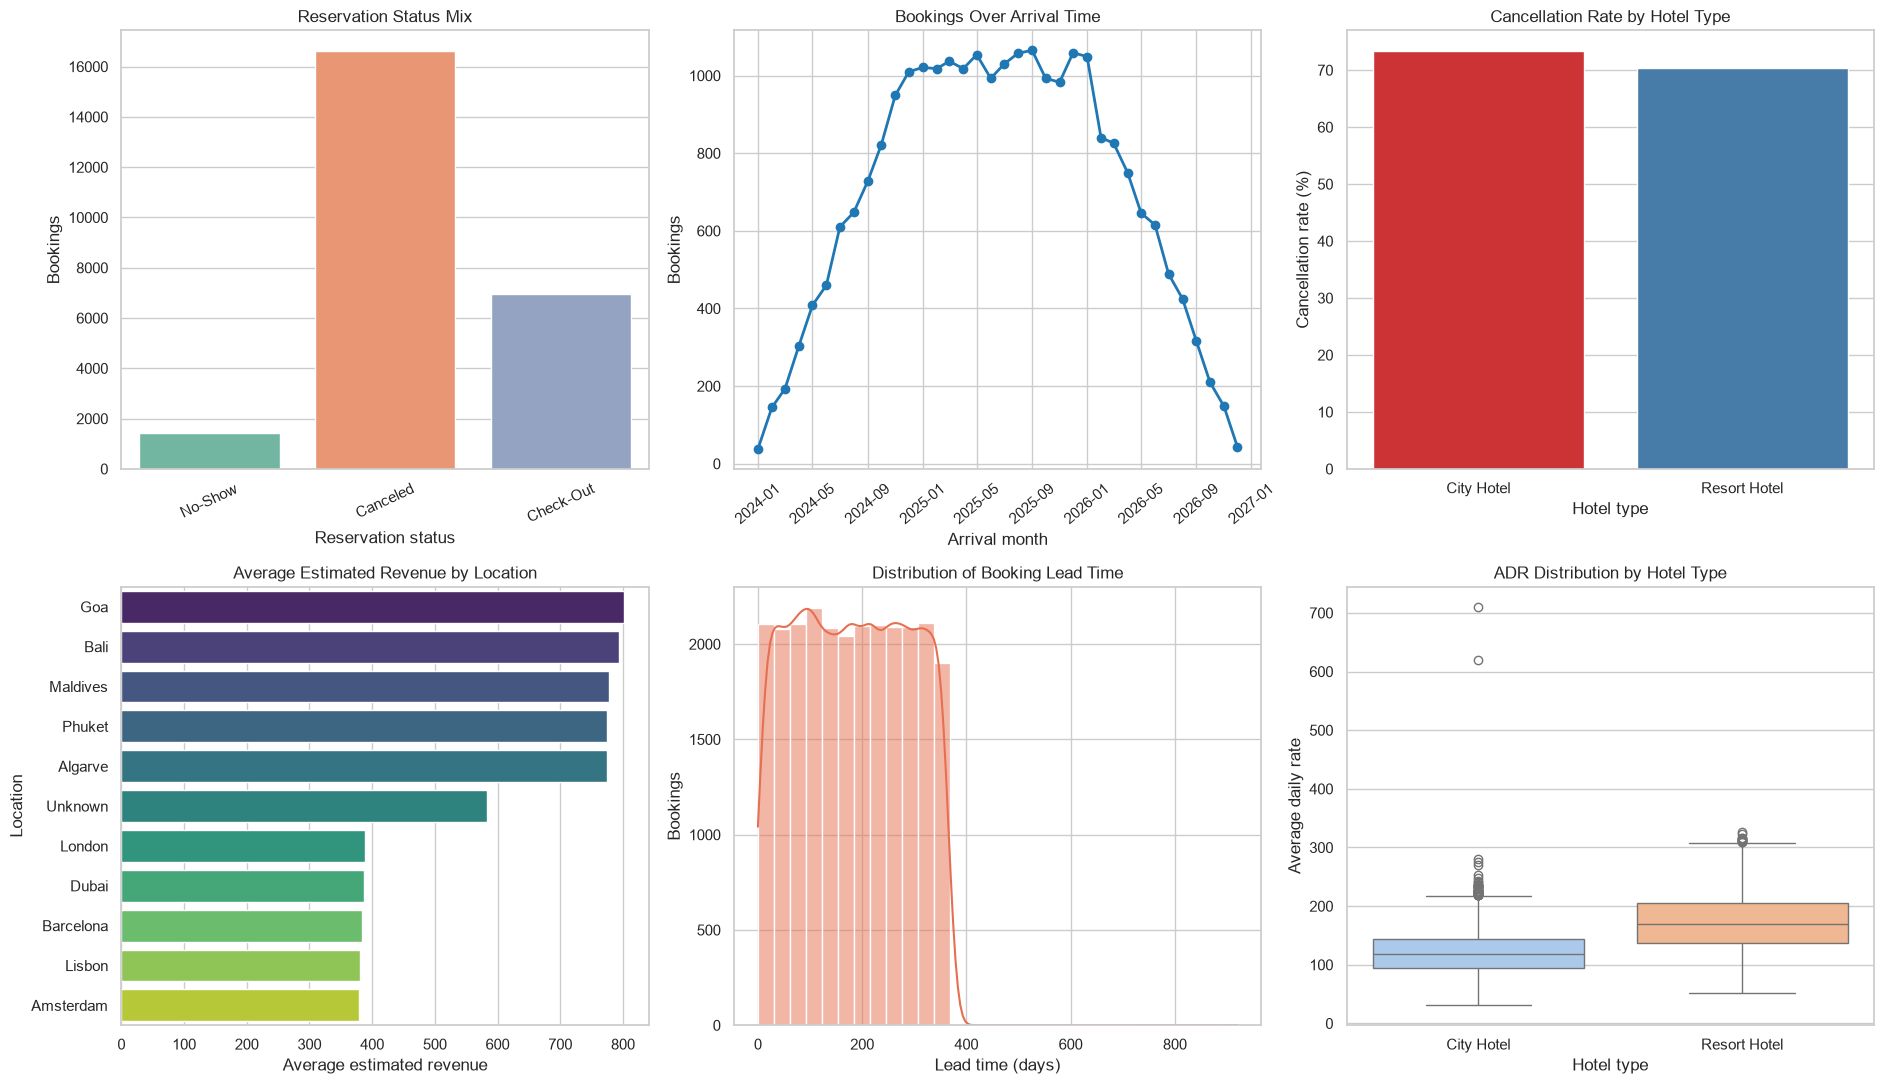

Interpretation: City Hotel has the higher cancellation rate. Goa leads average estimated revenue, and the lead-time histogram shows the booking window distribution. The ADR box plot compares price level and spread between hotel types.


In [9]:
sns.set_theme(style='whitegrid', context='notebook')
fig, axes = plt.subplots(2, 3, figsize=(19, 11))

sns.countplot(data=df, x='Reservation_Status', hue='Reservation_Status', legend=False, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Reservation Status Mix')
axes[0, 0].set_xlabel('Reservation status')
axes[0, 0].set_ylabel('Bookings')
axes[0, 0].tick_params(axis='x', rotation=25)

monthly_bookings = df.set_index('Arrival_Date').resample('MS').size()
axes[0, 1].plot(monthly_bookings.index, monthly_bookings.values, marker='o', color='#1f77b4', linewidth=2)
axes[0, 1].set_title('Bookings Over Arrival Time')
axes[0, 1].set_xlabel('Arrival month')
axes[0, 1].set_ylabel('Bookings')
axes[0, 1].tick_params(axis='x', rotation=40)

hotel_cancel = df.groupby('Hotel_Type', as_index=False)['Is_Canceled'].mean().assign(Is_Canceled=lambda data: data['Is_Canceled'] * 100)
sns.barplot(data=hotel_cancel, x='Hotel_Type', y='Is_Canceled', hue='Hotel_Type', legend=False, ax=axes[0, 2], palette='Set1')
axes[0, 2].set_title('Cancellation Rate by Hotel Type')
axes[0, 2].set_xlabel('Hotel type')
axes[0, 2].set_ylabel('Cancellation rate (%)')

location_revenue = df.groupby('Hotel_Location', as_index=False)['Estimated_Revenue'].mean().sort_values('Estimated_Revenue', ascending=False)
sns.barplot(data=location_revenue, x='Estimated_Revenue', y='Hotel_Location', hue='Hotel_Location', legend=False, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Average Estimated Revenue by Location')
axes[1, 0].set_xlabel('Average estimated revenue')
axes[1, 0].set_ylabel('Location')

sns.histplot(data=df, x='Lead_Time_Days', bins=30, kde=True, color='#e76f51', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Booking Lead Time')
axes[1, 1].set_xlabel('Lead time (days)')
axes[1, 1].set_ylabel('Bookings')

sns.boxplot(data=df, x='Hotel_Type', y='ADR', hue='Hotel_Type', legend=False, ax=axes[1, 2], palette='pastel')
axes[1, 2].set_title('ADR Distribution by Hotel Type')
axes[1, 2].set_xlabel('Hotel type')
axes[1, 2].set_ylabel('Average daily rate')

plt.tight_layout()
plt.show()

print(f"Interpretation: {hotel_cancel.loc[hotel_cancel['Is_Canceled'].idxmax(), 'Hotel_Type']} has the higher cancellation rate. {location_revenue.iloc[0]['Hotel_Location']} leads average estimated revenue, and the lead-time histogram shows the booking window distribution. The ADR box plot compares price level and spread between hotel types.")

## 5. Bivariate, Group-wise, and Correlation Analysis

These comparisons test which commercial and operational dimensions are most associated with cancellation, pricing, and customer experience.

,Market_Segment,Cancellation_Rate,Average_Revenue,Bookings
4,Online TA,75.10,546.63,10852
1,Direct,71.22,550.96,3808
3,Offline TA/TO,70.42,541.23,5440
2,Groups,69.79,480.23,1910
0,Corporate,67.49,499.20,2990


,Hotel_Type,Bookings,Cancellation_Rate,Average_ADR,Average_Satisfaction,Average_Lead_Time
0,City Hotel,15611,73.30,120.72,3.85,182.93
1,Resort Hotel,9389,70.31,173.70,3.86,181.03


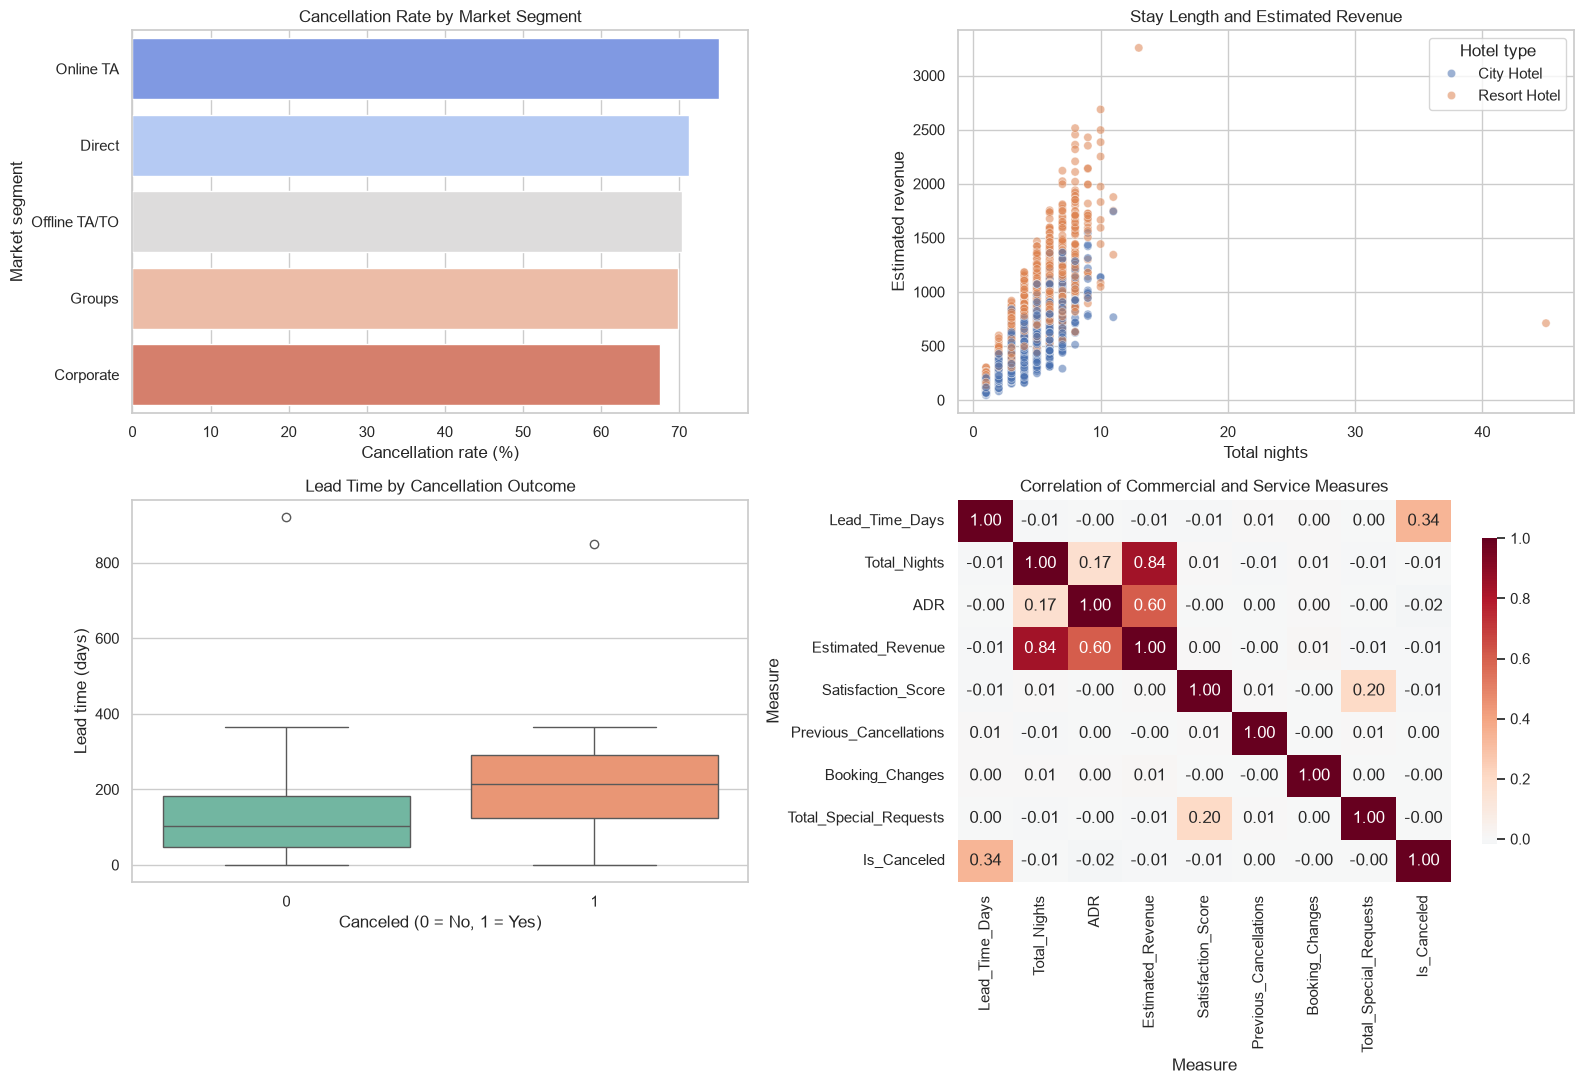

Interpretation: Online TA has the highest observed cancellation rate. Longer stays generally produce more estimated revenue, while the lead-time comparison shows how booking horizon differs between canceled and retained bookings. Correlations are descriptive and do not establish causation.


In [10]:
segment_analysis = df.groupby('Market_Segment', as_index=False).agg(
    Cancellation_Rate=('Is_Canceled', 'mean'),
    Average_Revenue=('Estimated_Revenue', 'mean'),
    Bookings=('Booking_ID', 'count')
).sort_values('Cancellation_Rate', ascending=False)
segment_analysis['Cancellation_Rate'] *= 100

group_analysis = df.groupby('Hotel_Type', as_index=False).agg(
    Bookings=('Booking_ID', 'count'),
    Cancellation_Rate=('Is_Canceled', 'mean'),
    Average_ADR=('ADR', 'mean'),
    Average_Satisfaction=('Satisfaction_Score', 'mean'),
    Average_Lead_Time=('Lead_Time_Days', 'mean')
)
group_analysis['Cancellation_Rate'] *= 100
display(segment_analysis.round(2))
display(group_analysis.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.barplot(data=segment_analysis, x='Cancellation_Rate', y='Market_Segment', hue='Market_Segment', legend=False, ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('Cancellation Rate by Market Segment')
axes[0, 0].set_xlabel('Cancellation rate (%)')
axes[0, 0].set_ylabel('Market segment')

sns.scatterplot(data=df.sample(min(4000, len(df)), random_state=42), x='Total_Nights', y='Estimated_Revenue', hue='Hotel_Type', alpha=0.55, ax=axes[0, 1])
axes[0, 1].set_title('Stay Length and Estimated Revenue')
axes[0, 1].set_xlabel('Total nights')
axes[0, 1].set_ylabel('Estimated revenue')
axes[0, 1].legend(title='Hotel type')

sns.boxplot(data=df, x='Is_Canceled', y='Lead_Time_Days', hue='Is_Canceled', legend=False, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Lead Time by Cancellation Outcome')
axes[1, 0].set_xlabel('Canceled (0 = No, 1 = Yes)')
axes[1, 0].set_ylabel('Lead time (days)')

correlation_columns = ['Lead_Time_Days', 'Total_Nights', 'ADR', 'Estimated_Revenue', 'Satisfaction_Score', 'Previous_Cancellations', 'Booking_Changes', 'Total_Special_Requests', 'Is_Canceled']
correlation_matrix = df[correlation_columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1, 1], cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Correlation of Commercial and Service Measures')
axes[1, 1].set_xlabel('Measure')
axes[1, 1].set_ylabel('Measure')

plt.tight_layout()
plt.show()

print(f"Interpretation: {segment_analysis.iloc[0]['Market_Segment']} has the highest observed cancellation rate. Longer stays generally produce more estimated revenue, while the lead-time comparison shows how booking horizon differs between canceled and retained bookings. Correlations are descriptive and do not establish causation.")

## 6. Executive Findings and Management Recommendations

The recommendations below are tied to the observed booking, cancellation, pricing, and service patterns. They should be validated with controlled experiments and realized revenue data before major policy changes.

In [11]:
top_location = location_revenue.iloc[0]
top_segment = segment_analysis.iloc[0]
city_cancel = hotel_cancel.loc[hotel_cancel['Is_Canceled'].idxmax()]
resort_row = group_analysis.loc[group_analysis['Hotel_Type'].eq('Resort Hotel')].iloc[0]

print('KEY BUSINESS INSIGHTS')
print(f"1. Cancellation is the largest commercial risk: {booking_summary['cancellation_rate_pct']:.1f}% of bookings are canceled, leaving only {100 - booking_summary['cancellation_rate_pct']:.1f}% as completed stays.")
print(f"2. Online TA is the highest-risk major segment at {top_segment['Cancellation_Rate']:.1f}% cancellation across {top_segment['Bookings']:,} bookings.")
print(f"3. City Hotels have a {city_cancel['Is_Canceled']:.1f}% cancellation rate versus {resort_row['Cancellation_Rate']:.1f}% for Resort Hotels, while resorts command a higher average ADR ({resort_row['Average_ADR']:.2f}).")
print(f"4. Goa leads average estimated revenue at {top_location['Estimated_Revenue']:.2f}; location mix should therefore inform inventory and promotion decisions.")
print(f"5. Estimated revenue is strongly associated with stay length (r={correlation_matrix.loc['Total_Nights', 'Estimated_Revenue']:.2f}), while longer lead time is moderately associated with cancellation (r={correlation_matrix.loc['Lead_Time_Days', 'Is_Canceled']:.2f}).")

print('\nMANAGEMENT RECOMMENDATIONS')
recommendations = [
    '1. Introduce deposit, payment, or flexible rebooking tiers for high-risk Online TA reservations, calibrated by lead time and cancellation history.',
    '2. Use a cancellation-risk dashboard by market segment, hotel type, arrival month, and lead-time band; review it weekly with revenue managers.',
    '3. Protect inventory for high-value long stays and test length-of-stay packages because stay length has the strongest relationship with estimated revenue.',
    '4. Prioritize revenue and marketing investment in Goa and other high-performing locations, but compare realized margin rather than estimated revenue alone.',
    '5. Use differentiated ADR and minimum-stay rules for Resort Hotels while monitoring demand elasticity and guest satisfaction.',
    '6. Audit the 652 IQR revenue outliers and 356 ADR outliers as a data-quality and yield-management queue; do not delete them automatically.'
]
print('\n'.join(recommendations))

KEY BUSINESS INSIGHTS
1. Cancellation is the largest commercial risk: 72.2% of bookings are canceled, leaving only 27.8% as completed stays.
2. Online TA is the highest-risk major segment at 75.1% cancellation across 10,852 bookings.
3. City Hotels have a 73.3% cancellation rate versus 70.3% for Resort Hotels, while resorts command a higher average ADR (173.70).
4. Goa leads average estimated revenue at 801.23; location mix should therefore inform inventory and promotion decisions.
5. Estimated revenue is strongly associated with stay length (r=0.84), while longer lead time is moderately associated with cancellation (r=0.34).

MANAGEMENT RECOMMENDATIONS
1. Introduce deposit, payment, or flexible rebooking tiers for high-risk Online TA reservations, calibrated by lead time and cancellation history.
2. Use a cancellation-risk dashboard by market segment, hotel type, arrival month, and lead-time band; review it weekly with revenue managers.
3. Protect inventory for high-value long stays a